# PEC 2 — Visualización de Datos
## Gráfico de Burbujas | Gráfico de Gofre | Gráfico de Marimekko

**Fuentes de datos:**
- **Bubble Chart:** Kaggle — Global Energy Mix & Generation Sources (agrupado por región, 2023). [Kaggle](https://www.kaggle.com/datasets/shreyasur965/hgfgfdgdsa)
- **Waffle Chart:** Kaggle — Global Energy Mix & Generation Sources (España, 2023). [Kaggle](https://www.kaggle.com/datasets/shreyasur965/hgfgfdgdsa)
- **Marimekko Chart:** Kaggle — Sales Dataset. [Kaggle](https://www.kaggle.com/datasets/vinothkannaece/sales-dataset)

# Librerías

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from pywaffle import Waffle

# Paleta de colores — Coolors
- https://coolors.co/palette/606c38-283618-fefae0-dda15e-bc6c25

In [ ]:
OLIVE      = "#606c38"
DARK_GREEN = "#283618"
CORNSILK   = "#fefae0"
EARTH      = "#dda15e"
BROWN      = "#bc6c25" 

# 1. Gráfico de Burbujas (Bubble Chart)

**Dataset:** `electricity-prod-source-stacked.csv` — [Kaggle — Global Energy Mix & Generation Sources](https://www.kaggle.com/datasets/shreyasur965/hgfgfdgdsa).  
Agrupamos por las 6 regiones mundiales disponibles en el dataset para el año 2023.

**Variables:** Generación total en TWh (eje X), porcentaje de renovables (eje Y), generación a partir de carbón en TWh (tamaño), región (color).

In [ ]:
df_elec = pd.read_csv("../data/electricity-prod-source-stacked.csv")

# Regiones mundiales disponibles (fuente Ember, año 2023)
regions = ["Africa (Ember)", "Asia (Ember)", "Europe (Ember)",
           "North America (Ember)", "Latin America and Caribbean (Ember)", "Oceania (Ember)"]

data = df_elec[(df_elec["Entity"].isin(regions)) & (df_elec["Year"] == 2023)].copy()

# Mapear columnas
col_map = {}
for col in df_elec.columns[3:]:
    cl = col.lower()
    if "wind" in cl: col_map["wind"] = col
    elif "gas" in cl: col_map["gas"] = col
    elif "nuclear" in cl: col_map["nuclear"] = col
    elif "solar" in cl: col_map["solar"] = col
    elif "hydro" in cl: col_map["hydro"] = col
    elif "oil" in cl: col_map["oil"] = col
    elif "bioenergy" in cl: col_map["bio"] = col
    elif "coal" in cl: col_map["coal"] = col
    elif "other" in cl: col_map["other_renew"] = col

# Calcular variables para el bubble chart
rows = []
for _, row in data.iterrows():
    total = sum(row[c] for c in col_map.values())
    renew = sum(row[col_map[k]] for k in ["wind", "solar", "hydro", "bio", "other_renew"] if k in col_map)
    pct_renew = renew / total * 100 if total > 0 else 0
    coal = row[col_map["coal"]]
    name = row["Entity"].replace(" (Ember)", "")
    rows.append({"Region": name, "Total_TWh": round(total, 1),
                 "Pct_renovable": round(pct_renew, 1), "Carbon_TWh": round(coal, 1)})

df_bubble = pd.DataFrame(rows)
print(f"{len(df_bubble)} regiones")
df_bubble.sort_values("Total_TWh", ascending=False)

6 regiones


,Region,Total_TWh,Pct_renovable,Carbon_TWh
1,Asia,15209.0,26.6,8585.5
2,Europe,4927.7,38.9,713.6
4,North America,4865.8,28.1,707.6
3,Latin America and Caribbean,1802.2,61.9,90.0
0,Africa,872.2,23.8,223.4
5,Oceania,323.1,41.1,130.4


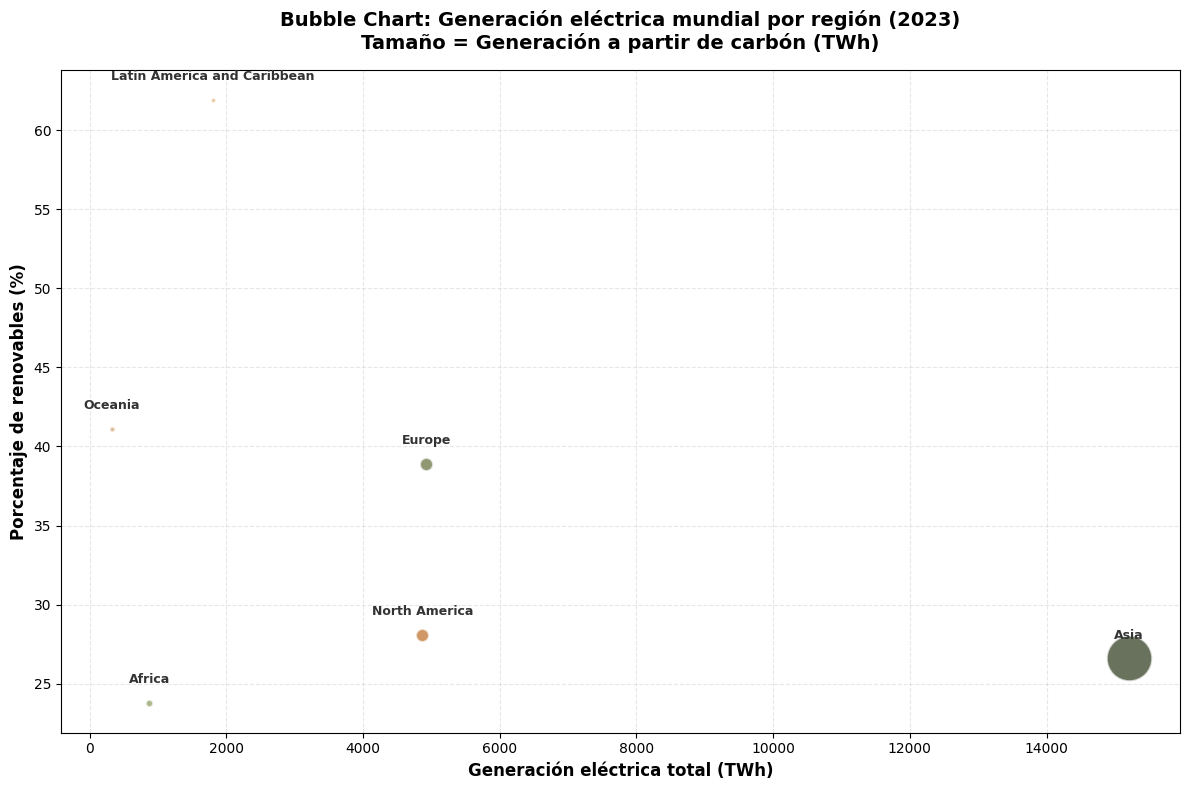

In [ ]:
REGION_COLORS = {
    "Asia":                          DARK_GREEN,
    "Europe":                        OLIVE,
    "North America":                 BROWN,
    "Latin America and Caribbean":   EARTH,
    "Africa":                        "#8a9a5b",
    "Oceania":                       "#d4a373",
}

fig, ax = plt.subplots(figsize=(12, 8))

for _, row in df_bubble.iterrows():
    ax.scatter(
        row["Total_TWh"],
        row["Pct_renovable"],
        s=row["Carbon_TWh"] / 8,
        c=REGION_COLORS.get(row["Region"], "#999999"),
        alpha=0.7,
        edgecolors="white",
        linewidth=1.5,
        label=row["Region"],
    )
    ax.annotate(
        row["Region"],
        (row["Total_TWh"], row["Pct_renovable"]),
        fontsize=9, ha="center", va="bottom",
        xytext=(0, 12), textcoords="offset points",
        fontweight="bold", color="#333333",
    )

ax.set_xlabel("Generación eléctrica total (TWh)", fontsize=12, fontweight="bold")
ax.set_ylabel("Porcentaje de renovables (%)", fontsize=12, fontweight="bold")
ax.set_title("Bubble Chart: Generación eléctrica mundial por región (2023)\nTamaño = Generación a partir de carbón (TWh)",
             fontsize=14, fontweight="bold", pad=15)
ax.grid(True, alpha=0.3, linestyle="--")
plt.tight_layout()
plt.savefig("../images/bubble_chart.png", dpi=150, bbox_inches="tight", facecolor="white")
plt.show()

# 2. Gráfico de Gofre (Waffle Chart)

**Dataset:** `electricity-prod-source-stacked.csv` — [Kaggle — Global Energy Mix & Generation Sources](https://www.kaggle.com/datasets/shreyasur965/hgfgfdgdsa).  
Filtramos España, año 2023. Cada cuadrado = 1% de la generación eléctrica total.

In [ ]:
df_elec = pd.read_csv("../data/electricity-prod-source-stacked.csv")

# Filtrar España, año 2023
spain = df_elec[(df_elec["Entity"] == "Spain") & (df_elec["Year"] == 2023)].iloc[0]

# Mapear columnas a nombres legibles
col_map = {}
for col in df_elec.columns[3:]:
    cl = col.lower()
    if "wind" in cl: col_map["Eólica"] = col
    elif "gas" in cl: col_map["Gas"] = col
    elif "nuclear" in cl: col_map["Nuclear"] = col
    elif "solar" in cl: col_map["Solar"] = col
    elif "hydro" in cl: col_map["Hidráulica"] = col
    elif "oil" in cl: col_map["Petróleo"] = col
    elif "bioenergy" in cl: col_map["Bioenergía"] = col
    elif "coal" in cl: col_map["Carbón"] = col
    elif "other" in cl: col_map["Otras renovables"] = col

sources = {name: spain[col] for name, col in col_map.items()}
total = sum(sources.values())

print("Generación eléctrica en España 2023 (TWh):")
for k, v in sorted(sources.items(), key=lambda x: -x[1]):
    print(f"  {k}: {v:.2f} TWh ({v/total*100:.1f}%)")
print(f"Total: {total:.2f} TWh")

Generación eléctrica en España 2023 (TWh):
  Eólica: 64.13 TWh (23.8%)
  Gas: 63.24 TWh (23.4%)
  Nuclear: 56.80 TWh (21.1%)
  Solar: 45.08 TWh (16.7%)
  Hidráulica: 20.01 TWh (7.4%)
  Petróleo: 10.73 TWh (4.0%)
  Bioenergía: 5.86 TWh (2.2%)
  Carbón: 3.90 TWh (1.4%)
Total: 269.75 TWh


In [ ]:
# Calcular porcentajes enteros para el waffle
pct_int = {k: round(v / total * 100) for k, v in sources.items()}
pct_int = {k: v for k, v in pct_int.items() if v > 0}

# Ajustar para que sumen exactamente 100
diff = 100 - sum(pct_int.values())
if diff != 0:
    max_key = max(pct_int, key=pct_int.get)
    pct_int[max_key] += diff

pct_int = dict(sorted(pct_int.items(), key=lambda x: -x[1]))
print(f"Porcentajes para el waffle (suman {sum(pct_int.values())}):")
for k, v in pct_int.items():
    print(f"  {k}: {v}%")

Porcentajes para el waffle (suman 100):
  Eólica: 25%
  Gas: 23%
  Nuclear: 21%
  Solar: 17%
  Hidráulica: 7%
  Petróleo: 4%
  Bioenergía: 2%
  Carbón: 1%


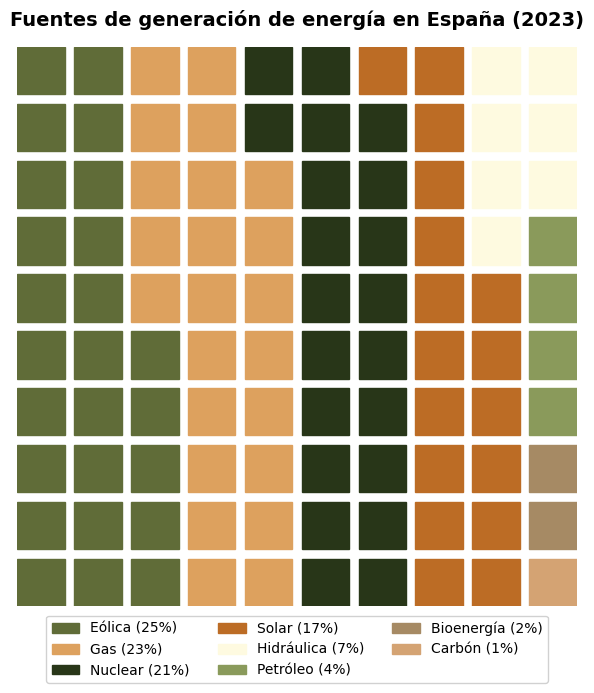

In [ ]:
WAFFLE_COLORS = [OLIVE, EARTH, DARK_GREEN, BROWN, CORNSILK, "#8a9a5b", "#a68a64", "#d4a373"]

fig = plt.figure(
    FigureClass=Waffle,
    rows=10,
    columns=10,
    values=pct_int,
    colors=WAFFLE_COLORS[:len(pct_int)],
    title={
        "label": "Fuentes de generación de energía en España (2023)",
        "loc": "center",
        "fontsize": 14,
        "fontweight": "bold",
        "pad": 15,
    },
    labels=[f"{k} ({v}%)" for k, v in pct_int.items()],
    legend={
        "loc": "lower center",
        "bbox_to_anchor": (0.5, -0.15),
        "ncol": 3,
        "fontsize": 10,
        "framealpha": 0.9,
    },
    figsize=(10, 7),
    block_arranging_style="snake",
)
plt.tight_layout()
plt.savefig("../images/waffle_chart.png", dpi=150, bbox_inches="tight", facecolor="white")
plt.show()

# 3. Gráfico de Marimekko (Marimekko Chart)

**Dataset:** `sales_data.csv` — [Kaggle Sales Dataset](https://www.kaggle.com/datasets/vinothkannaece/sales-dataset).  
**Anchura** = ventas totales de la región | **Altura** = proporción de cada categoría de producto.

In [ ]:
df_sales = pd.read_csv("../data/sales_data.csv")
print(f"{len(df_sales)} filas")
print(f"Regiones: {df_sales['Region'].unique()}")
print(f"Categorías: {df_sales['Product_Category'].unique()}")
df_sales.head()

1000 filas
Regiones: <StringArray>
['North', 'West', 'South', 'East']
Length: 4, dtype: str
Categorías: <StringArray>
['Furniture', 'Food', 'Clothing', 'Electronics']
Length: 4, dtype: str


,Product_ID,Sale_Date,Sales_Rep,Region,Sales_Amount,Quantity_Sold,Product_Category,Unit_Cost,Unit_Price,Customer_Type,Discount,Payment_Method,Sales_Channel,Region_and_Sales_Rep
0,1052,2023-02-03,Bob,North,5053.97,18,Furniture,152.75,267.22,Returning,0.09,Cash,Online,North-Bob
1,1093,2023-04-21,Bob,West,4384.02,17,Furniture,3816.39,4209.44,Returning,0.11,Cash,Retail,West-Bob
2,1015,2023-09-21,David,South,4631.23,30,Food,261.56,371.40,Returning,0.20,Bank Transfer,Retail,South-David
3,1072,2023-08-24,Bob,South,2167.94,39,Clothing,4330.03,4467.75,New,0.02,Credit Card,Retail,South-Bob
4,1061,2023-03-24,Charlie,East,3750.20,13,Electronics,637.37,692.71,New,0.08,Credit Card,Online,East-Charlie


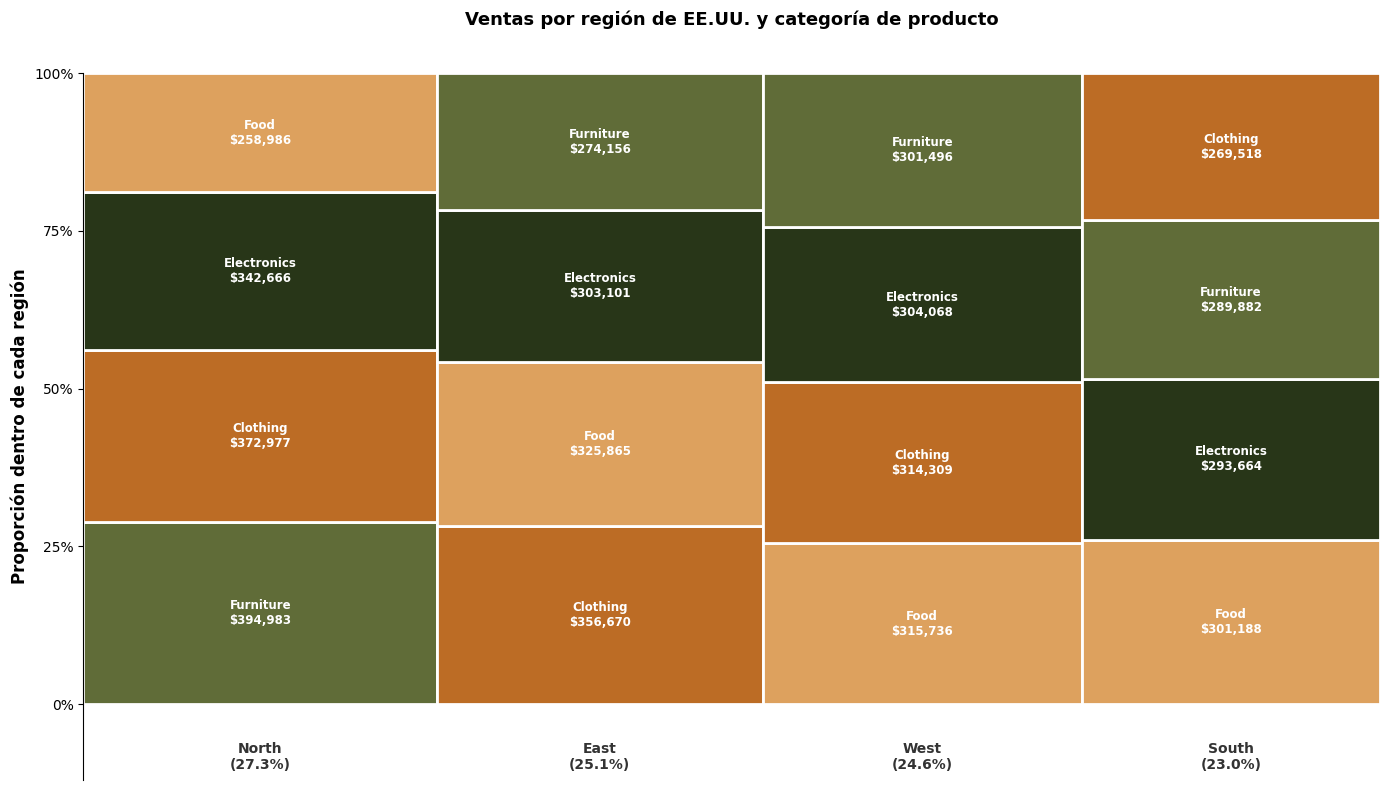

In [ ]:
CATEGORY_COLORS = {
    "Electronics": DARK_GREEN,
    "Furniture":   OLIVE,
    "Food":        EARTH,
    "Clothing":    BROWN,
}

region_totals = df_sales.groupby("Region")["Sales_Amount"].sum()
total_sales = region_totals.sum()
breakdown = df_sales.groupby(["Region", "Product_Category"])["Sales_Amount"].sum().reset_index()

fig, ax = plt.subplots(figsize=(14, 10))

x_start = 0
region_order = region_totals.sort_values(ascending=False).index

for region in region_order:
    region_width = region_totals[region] / total_sales
    region_data = breakdown[breakdown["Region"] == region].sort_values("Sales_Amount", ascending=False)
    y_start = 0

    for _, row in region_data.iterrows():
        height = row["Sales_Amount"] / region_totals[region]
        rect = plt.Rectangle(
            (x_start, y_start), region_width, height,
            facecolor=CATEGORY_COLORS.get(row["Product_Category"], "#cccccc"),
            edgecolor="white", linewidth=2,
        )
        ax.add_patch(rect)

        if height > 0.06 and region_width > 0.05:
            ax.text(
                x_start + region_width / 2,
                y_start + height / 2,
                f"{row['Product_Category']}\n${row['Sales_Amount']:,.0f}",
                ha="center", va="center",
                fontsize=8.5, color="white", fontweight="bold",
            )
        y_start += height

    pct = region_totals[region] / total_sales * 100
    ax.text(
        x_start + region_width / 2, -0.06,
        f"{region}\n({pct:.1f}%)",
        ha="center", va="top", fontsize=10, fontweight="bold", color="#333333",
    )
    x_start += region_width

legend_patches = [mpatches.Patch(color=c, label=cat) for cat, c in CATEGORY_COLORS.items()]

ax.set_xlim(0, 1)
ax.set_ylim(-0.12, 1)
ax.set_ylabel("Proporción dentro de cada región", fontsize=12, fontweight="bold")
ax.set_title("Ventas por región de EE.UU. y categoría de producto",
             fontsize=13, fontweight="bold", pad=35)
ax.set_xticks([])
ax.set_yticks([0, 0.25, 0.5, 0.75, 1.0])
ax.set_yticklabels(["0%", "25%", "50%", "75%", "100%"])
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.spines["bottom"].set_visible(False)
plt.tight_layout()
plt.savefig("../images/marimekko_chart.png", dpi=150, bbox_inches="tight", facecolor="white")
plt.show()